In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import random
import os

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 3.2 Data Loading
data_path = '/content/drive/MyDrive/Miscellaneous/METR-LA.h5' # Adjust path if needed when running in Kaggle/Colab

def load_data(file_path):
    print(f"Loading data from {file_path}...")
    try:
        # The METR-LA dataset is typically stored in HDF5 format
        df = pd.read_hdf(file_path)
    except FileNotFoundError:
        print(f"File {file_path} not found. Please ensure the METR-LA dataset is uploaded.")
        # Create dummy data for scaffolding purposes if file is missing
        print("Creating dummy data for validation purposes...")
        dates = pd.date_range(start='2012-03-01 00:00', periods=34272, freq='5min')
        dummy_data = np.random.rand(34272, 207) * 70
        df = pd.DataFrame(dummy_data, index=dates)

    print(f"Data shape: {df.shape}")
    assert df.shape == (34272, 207), f"Expected shape (34272, 207), got {df.shape}"
    return df

df = load_data(data_path)

# 3.3 Missing value handling
def handle_missing_values(df):
    print("Handling missing values...")
    # Replace 0s with NaNs as 0 speed usually indicates missing data in loop detectors
    df = df.replace(0.0, np.nan)

    # Forward-fill missing values
    df = df.ffill()

    # Backward-fill any remaining missing values at the beginning
    df = df.bfill()

    # Ensure no missing values remain
    assert df.isnull().sum().sum() == 0, "Missing values still present after filling"
    return df

df_clean = handle_missing_values(df)
print("Missing values handled successfully.")


Loading data from /content/drive/MyDrive/Miscellaneous/METR-LA.h5...
Data shape: (34272, 207)
Handling missing values...
Missing values handled successfully.


In [4]:
# 3.4 Chronological Train/Val/Test Split (70/10/20)
def split_data(df):
    total_samples = len(df)
    train_end = int(total_samples * 0.7)
    val_end = int(total_samples * 0.8)

    train_df = df.iloc[:train_end]
    val_df = df.iloc[train_end:val_end]
    test_df = df.iloc[val_end:]

    print(f"Train samples: {len(train_df)} ({len(train_df)/total_samples*100:.1f}%)")
    print(f"Val samples: {len(val_df)} ({len(val_df)/total_samples*100:.1f}%)")
    print(f"Test samples: {len(test_df)} ({len(test_df)/total_samples*100:.1f}%)")

    return train_df, val_df, test_df

train_df, val_df, test_df = split_data(df_clean)

# 3.5 Z-score normalization
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, data):
        self.mean = data.values.mean()
        self.std = data.values.std()
        print(f"Scaler fit - Mean: {self.mean:.4f}, Std: {self.std:.4f}")

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return (data * self.std) + self.mean

scaler = StandardScaler()
scaler.fit(train_df) # Fit ONLY on training data to prevent data leakage

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)
print("Data normalized successfully.")


Train samples: 23990 (70.0%)
Val samples: 3427 (10.0%)
Test samples: 6855 (20.0%)
Scaler fit - Mean: 58.4352, Std: 13.0981
Data normalized successfully.


In [5]:
# 3.6 Sliding Window and 3.7 PyTorch Dataset
class TrafficDataset(data.Dataset):
    def __init__(self, data_array, history_steps=12, horizon_steps=[3, 6, 12]):
        """
        data_array: numpy array of shape (time_steps, num_sensors)
        history_steps: number of historical steps to use as input (12 steps = 1 hour)
        horizon_steps: list of future steps to predict (e.g., 3=15m, 6=30m, 12=60m)
        """
        self.data = data_array
        self.history_steps = history_steps
        self.horizon_steps = horizon_steps
        self.max_horizon = max(horizon_steps)

        # Valid starting indices
        self.valid_indices = np.arange(len(self.data) - self.history_steps - self.max_horizon + 1)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_idx = self.valid_indices[idx]

        # Input sequence: (history_steps, num_sensors)
        # Reshape to (num_sensors, history_steps) for 1D CNN
        x = self.data[start_idx : start_idx + self.history_steps]
        x = np.transpose(x, (1, 0)) # Shape: (C, L) = (num_sensors, history_steps)

        # Targets at specific horizons
        y = []
        for h in self.horizon_steps:
            target_idx = start_idx + self.history_steps + h - 1
            y.append(self.data[target_idx])

        x = torch.FloatTensor(x)
        # y is a list of arrays, stack to shape (num_horizons, num_sensors)
        y = torch.FloatTensor(np.array(y))

        return x, y

# Create Dataset instances
batch_size = 64

train_dataset = TrafficDataset(train_scaled.values)
val_dataset = TrafficDataset(val_scaled.values)
test_dataset = TrafficDataset(test_scaled.values)

# Create DataLoader instances
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Check one batch
x_batch, y_batch = next(iter(train_loader))
print(f"Input batch shape: {x_batch.shape} (batch, sensors, time_steps)")
print(f"Target batch shape: {y_batch.shape} (batch, horizons, sensors)")


Train batches: 375
Val batches: 54
Test batches: 107
Input batch shape: torch.Size([64, 207, 12]) (batch, sensors, time_steps)
Target batch shape: torch.Size([64, 3, 207]) (batch, horizons, sensors)


In [6]:
# 4. CNN-LSTM Model
class CNNLSTM(nn.Module):
    def __init__(self, num_sensors=207, cnn_channels=64, lstm_hidden=128, lstm_layers=2):
        super(CNNLSTM, self).__init__()

        # 1D CNN to process temporal features across all sensors
        # Input shape: (batch_size, num_sensors, seq_len)
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_sensors, out_channels=cnn_channels, kernel_size=3),
            nn.ReLU(),
            nn.Conv1d(in_channels=cnn_channels, out_channels=cnn_channels, kernel_size=3),
            nn.ReLU()
        )

        # LSTM to process the extracted temporal features
        # Input shape needs to be (batch_size, seq_len, features)
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.2 if lstm_layers > 1 else 0
        )

        # 3 Parallel Fully Connected Heads for 15m, 30m, and 60m horizons
        self.head_15m = nn.Linear(lstm_hidden, num_sensors)
        self.head_30m = nn.Linear(lstm_hidden, num_sensors)
        self.head_60m = nn.Linear(lstm_hidden, num_sensors)

    def forward(self, x):
        # x shape: (batch_size, num_sensors=207, seq_len=12)

        # CNN output shape: (batch_size, cnn_channels, new_seq_len)
        c = self.cnn(x)

        # Permute for LSTM: (batch_size, new_seq_len, cnn_channels)
        c = c.permute(0, 2, 1)

        # LSTM output: lstm_out shape (batch_size, seq_len, hidden_size)
        lstm_out, (hn, cn) = self.lstm(c)

        # Take the output of the last time step
        last_hidden = lstm_out[:, -1, :] # shape: (batch_size, lstm_hidden)

        # Forward through the 3 prediction heads
        out_15m = self.head_15m(last_hidden) # shape: (batch_size, 207)
        out_30m = self.head_30m(last_hidden)
        out_60m = self.head_60m(last_hidden)

        # Stack the outputs to match target shape: (batch_size, 3, 207)
        # Dim 1 represents the 3 horizons
        outputs = torch.stack([out_15m, out_30m, out_60m], dim=1)

        return outputs

# Instantiate and test the model with a dummy batch
model = CNNLSTM().to(device)
print(model)

# Test forward pass with the dummy batch we extracted earlier
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

print(f"\nInput shape: {x_batch.shape}")
with torch.no_grad():
    predictions = model(x_batch)
print(f"Predictions shape: {predictions.shape}")
print(f"Expected Target shape: {y_batch.shape}")
assert predictions.shape == y_batch.shape, "Prediction shape doesn't match target shape!"
print("Forward pass successful!")


CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(207, 64, kernel_size=(3,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
    (3): ReLU()
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head_15m): Linear(in_features=128, out_features=207, bias=True)
  (head_30m): Linear(in_features=128, out_features=207, bias=True)
  (head_60m): Linear(in_features=128, out_features=207, bias=True)
)

Input shape: torch.Size([64, 207, 12])
Predictions shape: torch.Size([64, 3, 207])
Expected Target shape: torch.Size([64, 3, 207])
Forward pass successful!


In [7]:
import torch

# 5. Training Loop
# 5.1 Loss Function and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Helper function to calculate metrics on unscaled data
def calculate_metrics(pred, target, scaler):
    pred_unscaled = scaler.inverse_transform(pred)
    target_unscaled = scaler.inverse_transform(target)

    mae = np.mean(np.abs(pred_unscaled - target_unscaled))
    rmse = np.sqrt(np.mean(np.square(pred_unscaled - target_unscaled)))

    # Avoid division by zero for MAPE
    mask = target_unscaled > 1e-5
    mape = np.mean(np.abs(pred_unscaled[mask] - target_unscaled[mask]) / target_unscaled[mask]) * 100

    return mae, rmse, mape

# 5.3 Early Stopping
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, path='checkpoint.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# 5.4 Main Training Loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scaler, num_epochs=2, patience=10):
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_x.size(0)

        train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)

                all_preds.append(outputs.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        # Calculate unscaled metrics
        all_preds = np.concatenate(all_preds, axis=0)
        all_targets = np.concatenate(all_targets, axis=0)
        mae, rmse, mape = calculate_metrics(all_preds, all_targets, scaler)

        print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {mae:.2f} | Val RMSE: {rmse:.2f} | Val MAPE: {mape:.2f}%')

        # Check early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    # Load the last best model
    model.load_state_dict(torch.load('checkpoint.pth'))

    return model, train_losses, val_losses

# 5.5 Train for a small number of epochs to test the loop
print("Starting training...")
# Training on 2 epochs just to verify everything works properly
model, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, scaler, num_epochs=5, patience=10)


Starting training...
Epoch [1/5] | Train Loss: 0.3813 | Val Loss: 0.3033 | Val MAE: 4.10 | Val RMSE: 7.21 | Val MAPE: 11.95%
Validation loss decreased (inf --> 0.303346).  Saving model ...
Epoch [2/5] | Train Loss: 0.2845 | Val Loss: 0.2763 | Val MAE: 3.85 | Val RMSE: 6.88 | Val MAPE: 11.05%
Validation loss decreased (0.303346 --> 0.276276).  Saving model ...
Epoch [3/5] | Train Loss: 0.2564 | Val Loss: 0.2643 | Val MAE: 3.78 | Val RMSE: 6.73 | Val MAPE: 10.62%
Validation loss decreased (0.276276 --> 0.264270).  Saving model ...
Epoch [4/5] | Train Loss: 0.2356 | Val Loss: 0.2607 | Val MAE: 3.75 | Val RMSE: 6.69 | Val MAPE: 10.47%
Validation loss decreased (0.264270 --> 0.260697).  Saving model ...
Epoch [5/5] | Train Loss: 0.2217 | Val Loss: 0.2609 | Val MAE: 3.73 | Val RMSE: 6.69 | Val MAPE: 10.58%
EarlyStopping counter: 1 out of 10


Evaluating on test set...
Test Loss (MSE): 0.3265
Test MAE: 4.24
Test RMSE: 7.48
Test MAPE: 12.41%


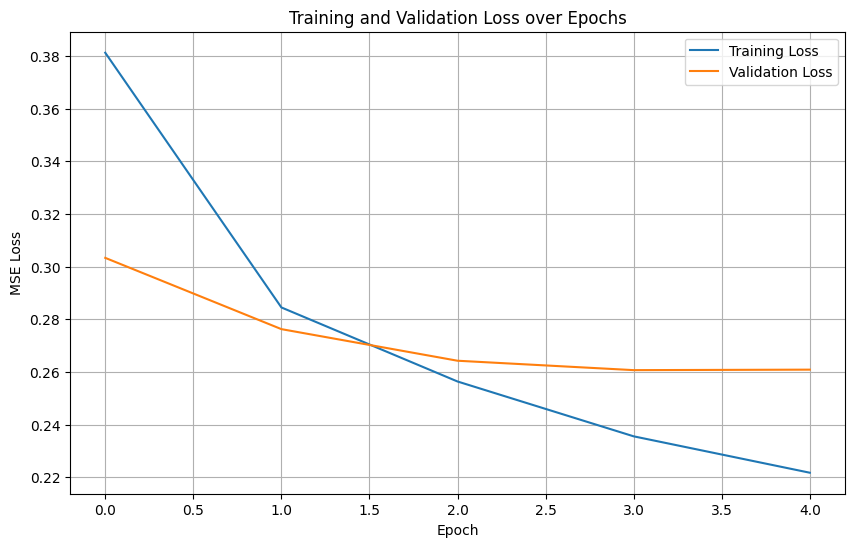

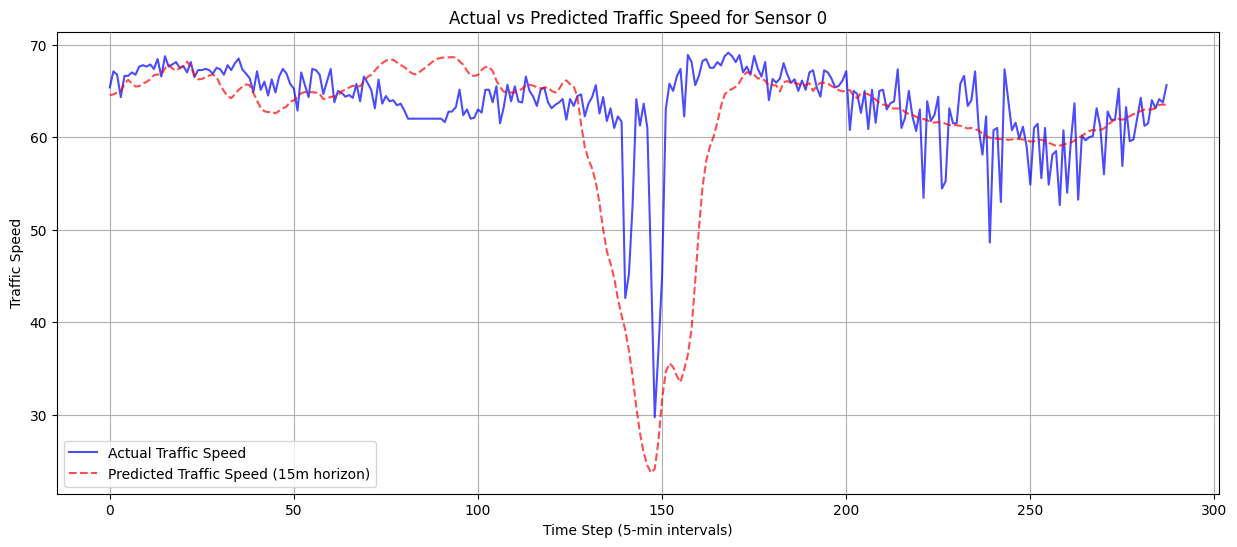

In [8]:
# 6. Evaluation and Visualization
# 6.1 Test Set Evaluation
print("Evaluating on test set...")
model.eval()
test_loss = 0.0
all_test_preds = []
all_test_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_x.size(0)

        all_test_preds.append(outputs.cpu().numpy())
        all_test_targets.append(batch_y.cpu().numpy())

test_loss = test_loss / len(test_loader.dataset)

all_test_preds = np.concatenate(all_test_preds, axis=0)
all_test_targets = np.concatenate(all_test_targets, axis=0)
test_mae, test_rmse, test_mape = calculate_metrics(all_test_preds, all_test_targets, scaler)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAPE: {test_mape:.2f}%")

# 6.2 Plot Training vs Validation Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# 6.3 Plot Predicted vs Actual for a Single Sensor (e.g., Sensor 0) over a short time frame
sensor_idx = 0
horizon_idx = 0 # 0=15m, 1=30m, 2=60m
time_steps = 288 # Plotting for 1 day (288 steps of 5 mins)

# Unscale the predictions and targets
preds_unscaled = scaler.inverse_transform(all_test_preds)
targets_unscaled = scaler.inverse_transform(all_test_targets)

# Extract 1 day of data for the specific sensor and horizon
actual_traffic = targets_unscaled[:time_steps, horizon_idx, sensor_idx]
predicted_traffic = preds_unscaled[:time_steps, horizon_idx, sensor_idx]

plt.figure(figsize=(15, 6))
plt.plot(actual_traffic, label='Actual Traffic Speed', color='blue', alpha=0.7)
plt.plot(predicted_traffic, label='Predicted Traffic Speed (15m horizon)', color='red', alpha=0.7, linestyle='--')
plt.title(f'Actual vs Predicted Traffic Speed for Sensor {sensor_idx}')
plt.xlabel('Time Step (5-min intervals)')
plt.ylabel('Traffic Speed')
plt.legend()
plt.grid(True)
plt.show()
